# CLAMPfull single-cell B-matrix recovery

Individual cells are projected into each 100%-sample CLAMPfull model using the full-data benchmark LV assignments. For every assigned LV, the top 1% of individual cells are evaluated against their true labels. Lung uses `ann_level_2`; Heart uses a deterministic 400,000-cell sample. The same sparse chunked projection implementation is used for every dataset.

## Parameters

In [1]:
OUT_DIR = 'output/03_model_biology/02_pseudobulk/03_b_matrix_singlecell'
MODEL_ROOT = 'output/01_model_building/05_pseudobulk'
ASSIGNMENTS_FILE = 'output/03_model_biology/02_pseudobulk/00_benchmark/clampfull_lv_assignments.csv'
DATASETS_PARAM = 'Brain_Mathys2023,Brain_Xiong2023,Heart_Datar2026,PBMC_1k1k,PBMC_Perez2022,Lung_Sikkema2023'
RAW_INPUTS_PARAM = ''
TOP_PCT = 0.01
HEART_MAX_CELLS = 400000
SEED = 0

In [2]:
# Parameters
DATASETS_PARAM = "Brain_Mathys2023,Brain_Xiong2023,Heart_Datar2026,PBMC_1k1k,PBMC_Perez2022,Lung_Sikkema2023"
RAW_INPUTS_PARAM = "data/pseudobulk/raw/Brain_Mathys2023/ad430_matrix.mtx.gz|data/pseudobulk/raw/Brain_Xiong2023/matrix.mtx.gz|data/pseudobulk/Heart_Datar2026/HeartMap_V1.0_raw_counts.h5ad|data/pseudobulk/raw/PBMC_1k1k/PBMC_1k1k_raw.h5ad|data/pseudobulk/raw/PBMC_Perez2022/PBMC_Perez2022_raw.h5ad|data/pseudobulk/Lung_Sikkema2023/lung_HLCA.h5ad"
MODEL_ROOT = "output/01_model_building/05_pseudobulk"
ASSIGNMENTS_FILE = "output/03_model_biology/02_pseudobulk/00_benchmark/clampfull_lv_assignments.csv"
OUT_DIR = "output/03_model_biology/02_pseudobulk/03_b_matrix_singlecell"


## Setup

In [3]:
from pathlib import Path
import pathlib, gzip, time, subprocess, gc
import numpy as np
import pandas as pd
import scipy.sparse as sp
import h5py
import matplotlib.pyplot as plt

ROOT = Path.cwd()
MOD_ROOT = ROOT / MODEL_ROOT
DATA_DIR = ROOT / 'data/pseudobulk'
RAW_STAGING = DATA_DIR / 'raw'
OUT_DIR = ROOT / OUT_DIR
SC_DIR = OUT_DIR / 'single_cell_export'
OUT_ROOT = SC_DIR
ASSIGNMENTS_PATH = ROOT / ASSIGNMENTS_FILE
OUT_DIR.mkdir(parents=True, exist_ok=True)
SC_DIR.mkdir(parents=True, exist_ok=True)
DATASET_NAMES = DATASETS_PARAM.split(',')
if RAW_INPUTS_PARAM:
    raw_values = RAW_INPUTS_PARAM.split('|')
    if len(raw_values) != len(DATASET_NAMES):
        raise ValueError('RAW_INPUTS_PARAM and DATASETS_PARAM differ in length')
    RAW_INPUTS = dict(zip(DATASET_NAMES, map(Path, raw_values)))
else:
    RAW_INPUTS = {
        'Brain_Mathys2023': Path('data/pseudobulk/raw/Brain_Mathys2023/ad430_matrix.mtx.gz'),
        'Brain_Xiong2023': Path('data/pseudobulk/raw/Brain_Xiong2023/matrix.mtx.gz'),
        'Heart_Datar2026': Path('data/pseudobulk/Heart_Datar2026/HeartMap_V1.0_raw_counts.h5ad'),
        'PBMC_1k1k': Path('data/pseudobulk/raw/PBMC_1k1k/PBMC_1k1k_raw.h5ad'),
        'PBMC_Perez2022': Path('data/pseudobulk/raw/PBMC_Perez2022/PBMC_Perez2022_raw.h5ad'),
        'Lung_Sikkema2023': Path('data/pseudobulk/Lung_Sikkema2023/lung_HLCA.h5ad'),
    }
RAW_INPUTS = {k: (ROOT / v if not v.is_absolute() else v) for k, v in RAW_INPUTS.items()}

## Functions: single-cell CPM export

In [4]:
def load_z_genes(dataset):
    z_path = MOD_ROOT / dataset / "CLAMPfull" / "Z.csv"
    genes = set(pd.read_csv(z_path, index_col=0).index.astype(str))
    print(f"[{dataset}] {len(genes)} genes in CLAMPfull Z")
    return genes


def _decode_str_array(arr):
    if arr.dtype.kind == "S" or arr.dtype == object:
        return np.array([x.decode() if isinstance(x, bytes) else x for x in arr]).astype(str)
    return arr.astype(str)


def _read_h5_str_field(node):
    if isinstance(node, h5py.Group):
        codes = node["codes"][:]
        cats = _decode_str_array(node["categories"][:])
        return cats[np.clip(codes, 0, len(cats) - 1)]
    return _decode_str_array(node[:])


def obs_index_field(h5):
    idx_name = h5["obs"].attrs.get("_index", "_index")
    return _read_h5_str_field(h5["obs"][idx_name])


def matrix_group(h5, matrix_name):
    key = "raw/X" if matrix_name == "raw.X" else matrix_name
    return h5[key]


def gene_names_h5(h5, matrix_name):
    var_group = h5["raw"]["var"] if matrix_name == "raw.X" and "raw" in h5 else h5["var"]
    for col in ("feature_name", "gene_name", "gene_symbols", "symbol"):
        if col in var_group:
            return _read_h5_str_field(var_group[col])
    idx_name = var_group.attrs.get("_index", "_index")
    return _read_h5_str_field(var_group[idx_name])


def read_csr_rows(group, start, stop, n_cols):
    indptr_full = group["indptr"][start:stop + 1]
    offset = int(indptr_full[0])
    end = int(indptr_full[-1])
    indptr = indptr_full - offset
    data = group["data"][offset:end].astype(np.float64, copy=False)
    indices = group["indices"][offset:end]
    return sp.csr_matrix((data, indices, indptr), shape=(stop - start, n_cols))


def collapse_duplicate_genes(mat_csr, gene_names):
    """mat_csr: cells x genes (already restricted). Average columns sharing a gene symbol."""
    uniq, inverse = np.unique(gene_names, return_inverse=True)
    if len(uniq) == len(gene_names):
        return mat_csr, gene_names
    counts = np.bincount(inverse, minlength=len(uniq))
    indicator = sp.csr_matrix(
        (np.ones(len(inverse)), (np.arange(len(inverse)), inverse)),
        shape=(len(gene_names), len(uniq)),
    )
    summed = mat_csr @ indicator
    summed = summed.multiply(1.0 / counts[None, :]).tocsr()
    print(f"  collapsed {len(gene_names)} -> {len(uniq)} unique gene symbols")
    return summed, uniq


def export_h5ad(dataset, h5ad_path, matrix_name, celltype_col, chunk_cells=20000,
                max_cells=None, seed=0):
    z_genes = load_z_genes(dataset)
    out_dir = OUT_ROOT / dataset
    out_dir.mkdir(parents=True, exist_ok=True)

    t0 = time.time()
    with h5py.File(h5ad_path, "r") as h5:
        genes = gene_names_h5(h5, matrix_name)
        group = matrix_group(h5, matrix_name)
        n_rows, n_cols = (int(x) for x in group.attrs["shape"])
        assert n_cols == len(genes), f"{n_cols} vs {len(genes)}"

        keep_gene_idx = np.where(np.isin(genes, list(z_genes)))[0]
        keep_genes = genes[keep_gene_idx]
        print(f"[{dataset}] {len(keep_gene_idx)}/{len(genes)} genes overlap Z; {n_rows} cells total")

        cell_id = obs_index_field(h5)
        cell_type = _read_h5_str_field(h5["obs"][celltype_col])
        selected = np.arange(n_rows)
        sample_mask = None
        if max_cells is not None and n_rows > max_cells:
            rng = np.random.default_rng(seed)
            selected = np.sort(rng.choice(n_rows, size=max_cells, replace=False))
            sample_mask = np.zeros(n_rows, dtype=bool)
            sample_mask[selected] = True
            print(f"[{dataset}] SUBSAMPLING {max_cells:,}/{n_rows:,} cells (seed={seed})")
        cell_id = cell_id[selected]
        cell_type = cell_type[selected]

        parts = []
        for start in range(0, n_rows, chunk_cells):
            stop = min(start + chunk_cells, n_rows)
            keep_rows = slice(None) if sample_mask is None else sample_mask[start:stop]
            if sample_mask is not None and not np.any(keep_rows):
                continue
            mat = read_csr_rows(group, start, stop, n_cols)[keep_rows, :]  # full genes, this chunk
            totals = np.asarray(mat.sum(axis=1)).ravel()  # FULL-transcriptome library size
            totals[totals == 0] = 1
            mat = mat.tocsc()[:, keep_gene_idx].tocsr()  # restrict AFTER computing totals
            cpm = mat.multiply(1e6 / totals[:, None]).tocsr()
            parts.append(cpm)
            if (start // chunk_cells) % 10 == 0:
                print(f"[{dataset}] {stop}/{n_rows} cells ({time.time() - t0:.0f}s)")

    full = sp.vstack(parts).tocsr()
    full, final_genes = collapse_duplicate_genes(full, keep_genes)

    sp.save_npz(out_dir / "cpm.npz", full)
    pd.Series(final_genes, name="gene").to_csv(out_dir / "genes.csv", index=False)
    pd.DataFrame({"cell_id": cell_id, "cell_type": cell_type}).to_csv(out_dir / "cell_meta.csv", index=False)
    print(f"[{dataset}] wrote {full.shape[0]} cells x {full.shape[1]} genes to {out_dir} "
          f"({time.time() - t0:.0f}s total)")


def read_mtx_streaming(path, chunk_rows=20_000_000, cell_mask=None):
    """Stream a gzipped Matrix Market file (genes x cells, 1-indexed) without ever
    materializing the full unfiltered matrix in memory. Returns (nrows, ncols,
    row_idx0, col_idx0, val) as flat 0-indexed numpy arrays. If `cell_mask` (boolean,
    length ncols) is given, entries for unmasked cells are dropped immediately per
    chunk and never accumulated -- for datasets too large to hold in full."""
    with gzip.open(path, "rt") as f:
        line = f.readline()
        while line.startswith("%"):
            line = f.readline()
        nrows, ncols, nnz = (int(x) for x in line.split())
        print(f"  mtx header: {nrows} genes x {ncols} cells, {nnz:,} nonzeros")

        row_parts, col_parts, val_parts = [], [], []
        reader = pd.read_csv(f, sep=" ", header=None, names=["row", "col", "val"],
                              dtype={"row": np.int32, "col": np.int32, "val": np.float64},
                              chunksize=chunk_rows)
        n_seen = 0
        for chunk in reader:
            r = chunk["row"].to_numpy() - 1
            c = chunk["col"].to_numpy() - 1
            v = chunk["val"].to_numpy()
            if cell_mask is not None:
                keep = cell_mask[c]
                r, c, v = r[keep], c[keep], v[keep]
            row_parts.append(r)
            col_parts.append(c)
            val_parts.append(v)
            n_seen += len(chunk)
            print(f"  parsed {n_seen:,}/{nnz:,} entries (kept so far: {sum(len(x) for x in val_parts):,})")
    return nrows, ncols, np.concatenate(row_parts), np.concatenate(col_parts), np.concatenate(val_parts)


def export_ucsc_mtx(dataset, matrix_fn, barcodes_fn, features_fn, celltype_col, chunk_cells=20000,
                     max_cells=None, seed=0):
    """max_cells: if the raw file is too large to hold entirely (post gene-filtering) in
    memory, randomly subsample this many cells BEFORE streaming (deterministic, seeded).
    Kept cells are a uniform random sample, so "top 1%" on the subsample remains an
    unbiased read on the population -- just a smaller (but still far larger than any
    pseudobulk-sample-level pool) one for datasets where the full population is
    infeasible to process on this machine."""
    z_genes = load_z_genes(dataset)
    raw_dir = pathlib.Path(RAW_INPUTS[dataset]).parent
    out_dir = OUT_ROOT / dataset
    out_dir.mkdir(parents=True, exist_ok=True)

    t0 = time.time()
    print(f"[{dataset}] streaming {matrix_fn} (chunked, gene-row-filtered)...")
    genes = pd.read_csv(raw_dir / features_fn, header=None)[0].astype(str).values
    meta = pd.read_csv(raw_dir / "meta.tsv", sep="\t")
    barcodes = pd.read_csv(raw_dir / barcodes_fn, header=None)[0].astype(str).values
    id_col = "cellId" if "cellId" in meta.columns else "cellName"
    assert (meta[id_col].astype(str).values == barcodes).all(), "meta.tsv/barcodes order mismatch"

    keep_gene_idx = np.where(np.isin(genes, list(z_genes)))[0]
    keep_genes = genes[keep_gene_idx]
    print(f"[{dataset}] {len(keep_gene_idx)}/{len(genes)} genes overlap Z; {len(barcodes)} cells total")

    cell_mask = None
    sampled_cell_idx = np.arange(len(barcodes))
    if max_cells is not None and len(barcodes) > max_cells:
        rng = np.random.default_rng(seed)
        sampled_cell_idx = np.sort(rng.choice(len(barcodes), size=max_cells, replace=False))
        cell_mask = np.zeros(len(barcodes), dtype=bool)
        cell_mask[sampled_cell_idx] = True
        print(f"[{dataset}] SUBSAMPLING {max_cells:,}/{len(barcodes):,} cells "
              f"(full population too large to process; seed={seed})")

    nrows, ncols, row0, col0_orig, val = read_mtx_streaming(raw_dir / matrix_fn, cell_mask=cell_mask)
    assert nrows == len(genes) and ncols == len(barcodes), \
        f"mtx shape {(nrows, ncols)} != features/barcodes {(len(genes), len(barcodes))}"

    # Remap original (possibly subsampled) column indices to a compact 0..n_kept_cells-1 range.
    col_lookup = -np.ones(ncols, dtype=np.int64)
    col_lookup[sampled_cell_idx] = np.arange(len(sampled_cell_idx))
    col0 = col_lookup[col0_orig]
    n_cells_kept = len(sampled_cell_idx)

    # FULL-transcriptome per-cell library size (before any gene filtering), over kept cells only.
    totals = np.zeros(n_cells_kept, dtype=np.float64)
    np.add.at(totals, col0, val)
    totals[totals == 0] = 1
    print(f"[{dataset}] library sizes computed ({time.time() - t0:.0f}s)")

    row_lookup = -np.ones(nrows, dtype=np.int64)
    row_lookup[keep_gene_idx] = np.arange(len(keep_gene_idx))
    new_row = row_lookup[row0]
    keep = new_row >= 0
    cpm_val = val[keep] * 1e6 / totals[col0[keep]]

    full = sp.csr_matrix((cpm_val, (col0[keep], new_row[keep])), shape=(n_cells_kept, len(keep_gene_idx)))
    del row0, col0, col0_orig, val, new_row, keep, cpm_val
    print(f"[{dataset}] gene-filtered CPM matrix built {full.shape} ({time.time() - t0:.0f}s)")

    full, final_genes = collapse_duplicate_genes(full, keep_genes)
    kept_barcodes = barcodes[sampled_cell_idx]
    kept_cell_type = meta[celltype_col].astype(str).values[sampled_cell_idx]

    sp.save_npz(out_dir / "cpm.npz", full)
    pd.Series(final_genes, name="gene").to_csv(out_dir / "genes.csv", index=False)
    pd.DataFrame({"cell_id": kept_barcodes, "cell_type": kept_cell_type}).to_csv(
        out_dir / "cell_meta.csv", index=False)
    print(f"[{dataset}] wrote {full.shape[0]} cells x {full.shape[1]} genes to {out_dir} "
          f"({time.time() - t0:.0f}s total)")




## Functions: label mapping, projection, and recovery

In [5]:
PBMC_1K1K_MAP = {
    "CD4_T": ["CD4 CTL", "CD4 Naive", "CD4 Proliferating", "CD4 TCM", "CD4 TEM", "Treg"],
    "CD8_T": ["CD8 Naive", "CD8 Proliferating", "CD8 TCM", "CD8 TEM"],
    "gd_T": ["gdT"],
    "B_cell": ["B intermediate", "B memory", "B naive"],
    "Plasma_B": ["Plasmablast"],
    "CD14_Mono": ["CD14 Mono"],
    "CD16_Mono": ["CD16 Mono"],
    "DC": ["cDC1", "cDC2", "ASDC"],
    "NK": ["NK", "NK Proliferating", "NK_CD56bright"],
}

PBMC_PEREZ2022_MAP = {
    "B_cell": ["B cell", "plasmablast"],
    "Myeloid": ["classical monocyte", "non-classical monocyte", "conventional dendritic cell",
                "plasmacytoid dendritic cell", "progenitor cell"],
    "NK": ["natural killer cell"],
    "T_cell": ["CD4-positive, alpha-beta T cell", "CD8-positive, alpha-beta T cell", "lymphocyte"],
}

HEART_DATAR2026_MAP = {
    "adipocyte": "Adipocyte",
    "regular atrial cardiac myocyte": "AtrialCM",
    "endocardial cell": "Endocardial",
    "cardiac endothelial cell": "Endothelial",
    "mesothelial cell of epicardium": "Epicardial",
    "fibroblast of cardiac tissue": "Fibroblast",
    "endothelial cell of lymphatic vessel": "LymphaticEndothelial",
    "lymphocyte": "Lymphocyte",
    "macrophage": "Macrophage",
    "mast cell": "Mast",
    "cardiac neuron": "Neuronal",
    "pericyte": "Pericyte",
    "vascular associated smooth muscle cell": "VSMC",
    "regular ventricular cardiac myocyte": "VentricularCM",
}

_LUNG_ANN2_CACHE = None


def _read_h5_str_field(node):
    import h5py
    if isinstance(node, h5py.Group):
        codes = node["codes"][:]
        cats = np.array([c.decode() if isinstance(c, bytes) else c for c in node["categories"][:]])
        return cats[np.clip(codes, 0, len(cats) - 1)]
    arr = node[:]
    if arr.dtype.kind == "S" or arr.dtype == object:
        return np.array([x.decode() if isinstance(x, bytes) else x for x in arr]).astype(str)
    return arr.astype(str)


def _load_lung_ann_level_2():
    """Lung_Sikkema2023 uses HLCA's ann_level_2 (11 coarse compartments) as its ONLY
    ground-truth resolution -- fits CLAMPfull's 18 LVs far better than the 17-19
    fine-grained ann_level_3 types (near 1:1, which left several fine types with only
    a weak/negative leftover LV). Looked up per-cell by cell_id directly from the raw
    h5ad (cell_meta.csv's own `cell_type` column is ann_level_3, from the original
    export) rather than re-exporting."""
    global _LUNG_ANN2_CACHE
    if _LUNG_ANN2_CACHE is None:
        import h5py
        path = pathlib.Path(RAW_INPUTS['Lung_Sikkema2023'])
        with h5py.File(path, "r") as f:
            idx_name = f["obs"].attrs.get("_index", "_index")
            cell_id = _read_h5_str_field(f["obs"][idx_name])
            lvl2 = _read_h5_str_field(f["obs"]["ann_level_2"])
        _LUNG_ANN2_CACHE = pd.Series(lvl2, index=cell_id)
    return _LUNG_ANN2_CACHE


def map_cell_type(dataset, meta):
    """Return a Series of mapped truthFrac_v0-style labels; unmapped cells -> NaN (dropped)."""
    raw = meta["cell_type"]
    if dataset in ("Brain_Xiong2023", "Brain_Mathys2023"):
        return raw  # identity
    if dataset == "Heart_Datar2026":
        return raw.map(HEART_DATAR2026_MAP)
    if dataset == "PBMC_1k1k":
        inv = {v: k for k, vs in PBMC_1K1K_MAP.items() for v in vs}
        return raw.map(inv)
    if dataset == "PBMC_Perez2022":
        inv = {v: k for k, vs in PBMC_PEREZ2022_MAP.items() for v in vs}
        return raw.map(inv)
    if dataset == "Lung_Sikkema2023":
        ann2 = _load_lung_ann_level_2()
        return meta["cell_id"].map(ann2)
    raise ValueError(dataset)


# --- pseudobulk-level LV<->cell-type assignment (one-to-one, max correlation) -----

def read_B(path):
    df = pd.read_csv(path, index_col=0)  # LVs x samples
    return df.T  # samples x LVs


def read_truth(path):
    df = pd.read_csv(path, index_col=0)  # samples x cell_types
    if len(df) <= 100:
        keep = df.mean(axis=0) >= 0.005
        df = df.loc[:, keep]
    return df


def one_to_one_assignment(fac, truth):
    shared = fac.index.intersection(truth.index)
    fac_s = fac.loc[shared]
    truth_s = truth.loc[shared]
    fac_s = fac_s.loc[:, fac_s.var(axis=0) > 0]

    cc = pd.DataFrame(index=fac_s.columns, columns=truth_s.columns, dtype=float)
    for lv in fac_s.columns:
        for ct in truth_s.columns:
            cc.loc[lv, ct] = np.corrcoef(fac_s[lv], truth_s[ct])[0, 1]
    cc = cc.astype(float)

    assignment = {}
    work = cc.copy()
    while work.notna().any().any() and work.shape[0] > 0 and work.shape[1] > 0:
        idx = work.stack().idxmax()
        lv, ct = idx
        assignment[ct] = (lv, cc.loc[lv, ct])
        work = work.drop(index=lv, errors="ignore").drop(columns=ct, errors="ignore")
        if work.empty:
            break
    return assignment  # {cell_type: (LV, cor)}


# --- single-cell projection --------------------------------------------------------

def project_cells_to_lv(cpm, genes, Z_full, L2, chunk_cells=50000):
    """Project all datasets with the same sparse, chunked ridge calculation."""
    common = [g for g in genes if g in Z_full.index]
    gene_idx = {g: i for i, g in enumerate(genes)}
    col_idx = np.array([gene_idx[g] for g in common])
    Z = Z_full.loc[common].to_numpy(dtype=np.float64)
    X = cpm[:, col_idx].tocsr()
    mu = np.asarray(X.mean(axis=0)).ravel()
    var = np.asarray(X.multiply(X).mean(axis=0)).ravel() - mu ** 2
    keep = var > 1e-12
    X = X[:, keep]; Z = Z[keep, :]; mu = mu[keep]
    sigma = np.sqrt(var[keep])
    Zs = Z / sigma[:, None]
    center = (mu / sigma) @ Z
    ridge = np.linalg.inv(Z.T @ Z + L2 * np.eye(Z.shape[1]))
    B = np.empty((X.shape[0], Z.shape[1]), dtype=np.float32)
    for start in range(0, X.shape[0], chunk_cells):
        stop = min(start + chunk_cells, X.shape[0])
        raw = np.asarray(X[start:stop] @ Zs) - center[None, :]
        B[start:stop] = (raw @ ridge).astype(np.float32)
    return B, list(Z_full.columns)


def read_benchmark_assignments(ds):
    assignments = pd.read_csv(ASSIGNMENTS_PATH)
    rows = assignments.loc[assignments["dataset"] == ds, ["cell_type", "LV", "cor"]]
    if rows.empty:
        raise ValueError(f"No full-data benchmark assignments for {ds}: {ASSIGNMENTS_PATH}")
    return {row.cell_type: (row.LV, row.cor) for row in rows.itertuples(index=False)}


def run_dataset(ds, L2_map):
    print(f"\n========== {ds} ==========")
    assignment = read_benchmark_assignments(ds)
    print(f"  {len(assignment)} full-data benchmark assignments loaded")

    sc_dir = SC_DIR / ds
    cpm = sp.load_npz(sc_dir / "cpm.npz")
    genes = pd.read_csv(sc_dir / "genes.csv")["gene"].tolist()
    meta = pd.read_csv(sc_dir / "cell_meta.csv")
    Z_full = pd.read_csv(MOD_ROOT / ds / "CLAMPfull" / "Z.csv", index_col=0)
    B_cells, lv_names = project_cells_to_lv(cpm, genes, Z_full, L2_map[ds])
    print(f"  projected {B_cells.shape[0]:,} cells onto {B_cells.shape[1]} LVs")
    meta["mapped_cell_type"] = map_cell_type(ds, meta)

    lv_col = {lv: i for i, lv in enumerate(lv_names)}
    cell_types = sorted(assignment.keys())
    n_cells = B_cells.shape[0]
    n_top = max(1, round(n_cells * TOP_PCT))

    count_mat = pd.DataFrame(0, index=cell_types, columns=cell_types)
    for col_ct in cell_types:
        lv, cor = assignment[col_ct]
        if lv not in lv_col:
            continue
        scores = B_cells[:, lv_col[lv]]
        top_idx = np.argpartition(-scores, n_top - 1)[:n_top]
        top_truth = meta["mapped_cell_type"].to_numpy()[top_idx]
        vc = pd.Series(top_truth).value_counts()
        for row_ct in cell_types:
            count_mat.loc[row_ct, col_ct] = vc.get(row_ct, 0)

    col_sums_raw = count_mat.sum(axis=0)
    col_sums = col_sums_raw.replace(0, 1)
    pct_mat = count_mat.div(col_sums, axis=1) * 100

    # --- prevalence-corrected metrics -------------------------------------------
    # Raw diagonal purity is capped by prevalence: a cell type with only n_c true
    # cells in the whole population can never exceed purity min(1, n_c/col_sum)
    # even with a perfect LV, where col_sum is the SAME denominator pct_mat
    # itself uses -- the count of top-1%-pool cells that have a defined cell-type
    # label (some pools include cells outside the dataset's cell-type scheme,
    # e.g. PBMC_1k1k's Doublet/Eryth/HSPC/ILC/MAIT, which get excluded from both
    # numerator and denominator, not counted as impurities). Using the pool size
    # n_top instead of col_sum here would understate the true ceiling whenever
    # col_sum < n_top, letting purity_ratio exceed 1 -- impossible by definition,
    # since diag_count can never exceed n_c: purity_ratio = observed/max_achievable
    # = (diag_count/col_sum)/(n_c/col_sum) = diag_count/n_c <= 1 always.
    # purity_lift = Pr(target | top-1%) / Pr(target) is a separate, uncapped
    # enrichment-over-baseline metric. `lift` generalizes the same idea to every
    # (row, col) cell, not just the diagonal.
    vc_pop = meta["mapped_cell_type"].value_counts()
    n_pop = vc_pop.sum()
    n_c = vc_pop.reindex(cell_types).fillna(0)
    prevalence = n_c / n_pop

    lift_mat = pct_mat.div(100).div(prevalence.replace(0, np.nan), axis=0)
    long_df = pct_mat.stack().rename("pct").reset_index()
    long_df.columns = ["row_cell_type", "col_cell_type", "pct"]
    long_df["count"] = count_mat.stack().to_numpy()
    long_df["lift"] = lift_mat.stack().reindex(
        pd.MultiIndex.from_arrays([long_df["row_cell_type"], long_df["col_cell_type"]])).to_numpy()
    long_df["dataset"] = ds

    # Ceiling uses each column's own mapped-pool size (col_sums), matching pct_mat's
    # actual denominator -- NOT the raw n_top -- so purity_ratio is guaranteed <= 1.
    max_achievable_purity = (n_c / col_sums.reindex(cell_types)).clip(upper=1.0)

    diag_rows = []
    for ct in cell_types:
        observed = pct_mat.loc[ct, ct] / 100
        max_ach = max_achievable_purity[ct]
        prev = prevalence[ct]
        diag_rows.append({
            "dataset": ds, "cell_type": ct, "n_top": n_top,
            "col_pool_size": col_sums_raw[ct],
            "diag_count": count_mat.loc[ct, ct], "recovery_pct": pct_mat.loc[ct, ct],
            "assigned_lv": assignment[ct][0], "assignment_cor": assignment[ct][1],
            "n_true_cells": n_c[ct], "n_population": n_pop, "prevalence": prev,
            "max_achievable_purity": max_ach,
            "purity_ratio": observed / max_ach if max_ach > 0 else np.nan,
            "purity_lift": observed / prev if prev > 0 else np.nan,
        })
    diag_df = pd.DataFrame(diag_rows)

    assign_df = pd.DataFrame(
        [{"dataset": ds, "cell_type": ct, "LV": lv, "cor": cor} for ct, (lv, cor) in assignment.items()])

    return long_df, diag_df, assign_df, n_cells




## Analysis: validate or create CPM intermediates

In [6]:
def validate_export(dataset):
    out = SC_DIR / dataset
    required = [out / 'cpm.npz', out / 'genes.csv', out / 'cell_meta.csv']
    if not all(p.exists() and p.stat().st_size > 0 for p in required):
        return False
    matrix = sp.load_npz(required[0])
    n_genes = len(pd.read_csv(required[1]))
    n_cells = len(pd.read_csv(required[2], usecols=['cell_id']))
    valid = matrix.shape == (n_cells, n_genes) and np.isfinite(matrix.data).all()
    del matrix
    gc.collect()
    print(f'[{dataset}] existing CPM export valid: {n_cells:,} cells x {n_genes:,} genes')
    return valid


def export_dataset(dataset):
    raw = RAW_INPUTS[dataset]
    if dataset == 'Heart_Datar2026':
        return export_h5ad(dataset, raw, 'X', 'cell_type__ontology_label',
                           max_cells=HEART_MAX_CELLS, seed=SEED)
    if dataset == 'PBMC_Perez2022':
        return export_h5ad(dataset, raw, 'raw.X', 'cell_type')
    if dataset == 'PBMC_1k1k':
        return export_h5ad(dataset, raw, 'X', 'predicted.celltype.l2')
    if dataset == 'Lung_Sikkema2023':
        return export_h5ad(dataset, raw, 'raw.X', 'ann_level_3')
    if dataset == 'Brain_Xiong2023':
        return export_ucsc_mtx(dataset, raw.name, 'barcodes.tsv.gz', 'features.tsv.gz', 'Celltype')
    if dataset == 'Brain_Mathys2023':
        return export_ucsc_mtx(dataset, raw.name, 'ad430_barcodes.tsv.gz',
                               'ad430_features.tsv.gz', 'Major_Cell_Type',
                               max_cells=400000, seed=SEED)
    raise ValueError(dataset)


for dataset in DATASET_NAMES:
    if not validate_export(dataset):
        export_dataset(dataset)
        if not validate_export(dataset):
            raise RuntimeError(f'Invalid export after rebuilding {dataset}')

[Brain_Mathys2023] existing CPM export valid: 400,000 cells x 14,830 genes


[Brain_Xiong2023] existing CPM export valid: 414,964 cells x 19,948 genes


[Heart_Datar2026] existing CPM export valid: 400,000 cells x 22,299 genes


[PBMC_1k1k] existing CPM export valid: 1,248,980 cells x 12,097 genes


[PBMC_Perez2022] existing CPM export valid: 1,263,676 cells x 11,049 genes


[Lung_Sikkema2023] existing CPM export valid: 584,944 cells x 17,145 genes


## Analysis, results, and exports


========== Brain_Mathys2023 ==========
  6 full-data benchmark assignments loaded


  projected 400,000 cells onto 19 LVs

========== Brain_Xiong2023 ==========
  6 full-data benchmark assignments loaded


  projected 414,964 cells onto 18 LVs

========== Heart_Datar2026 ==========
  14 full-data benchmark assignments loaded


  projected 400,000 cells onto 52 LVs

========== PBMC_1k1k ==========
  9 full-data benchmark assignments loaded


  projected 1,248,980 cells onto 96 LVs



========== PBMC_Perez2022 ==========
  4 full-data benchmark assignments loaded


  projected 1,263,676 cells onto 52 LVs



========== Lung_Sikkema2023 ==========
  8 full-data benchmark assignments loaded


  projected 584,944 cells onto 18 LVs


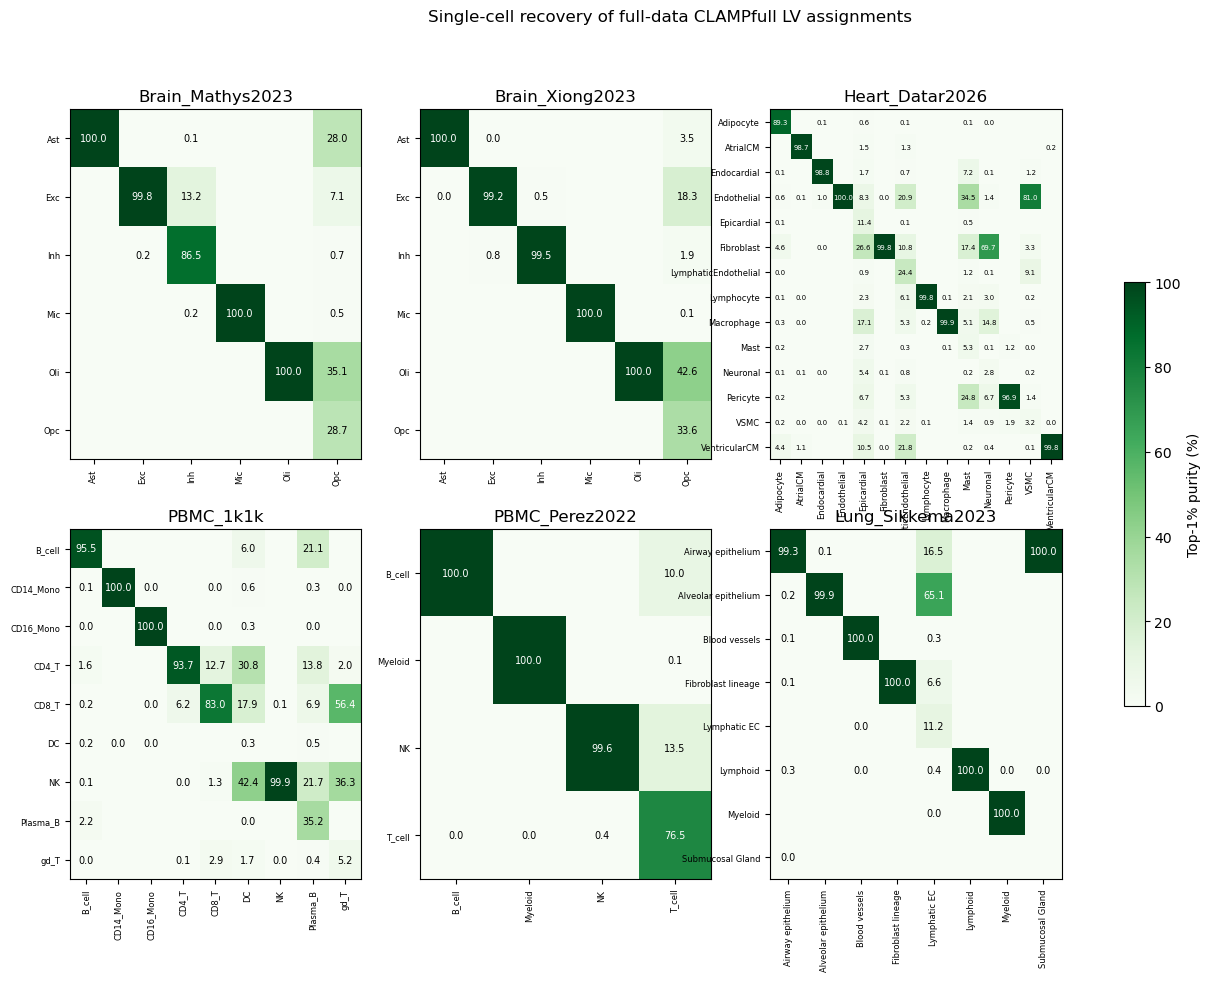

,scope,metric,value
0,canonical_6datasets,global_recovery_pct_pooled,75.364373
1,canonical_6datasets,mean_recovery_pct_by_dataset,79.892356
2,canonical_6datasets,mean_purity_ratio,0.801334
3,canonical_6datasets,mean_purity_lift,19.493307


In [7]:
def read_l2(dataset):
    model_path = MOD_ROOT / dataset / 'CLAMPfull' / 'CLAMPfull.rds'
    expression = "args <- commandArgs(TRUE); m <- readRDS(args[1]); cat(as.numeric(m$L2))"
    value = subprocess.check_output(['Rscript', '-e', expression, str(model_path)], text=True)
    return float(value.strip())


L2_map = {dataset: read_l2(dataset) for dataset in DATASET_NAMES}
all_long, all_diag, all_assign = [], [], []
for dataset in DATASET_NAMES:
    long_df, diag_df, assign_df, _ = run_dataset(dataset, L2_map)
    all_long.append(long_df); all_diag.append(diag_df); all_assign.append(assign_df)
    gc.collect()

heatmap_long = pd.concat(all_long, ignore_index=True)
diag_recovery = pd.concat(all_diag, ignore_index=True)
assignments_all = pd.concat(all_assign, ignore_index=True)

def summarize_scope(frame, scope):
    per_dataset = frame.groupby('dataset')['recovery_pct'].mean()
    values = {
        'global_recovery_pct_pooled': frame['diag_count'].sum() / frame['n_top'].sum() * 100,
        'mean_recovery_pct_by_dataset': per_dataset.mean(),
        'mean_purity_ratio': frame['purity_ratio'].mean(),
        'mean_purity_lift': frame['purity_lift'].mean(),
    }
    return pd.DataFrame({'scope': scope, 'metric': values.keys(), 'value': values.values()})

overall = summarize_scope(diag_recovery, 'canonical_6datasets')

purity_corrected = diag_recovery.rename(columns={
    'prevalence': 'prevalence_fraction', 'recovery_pct': 'recovery_pct',
    'max_achievable_purity': 'max_achievable_fraction'})

heatmap_long.to_csv(OUT_DIR / 'heatmap_long.csv', index=False)
diag_recovery.to_csv(OUT_DIR / 'recovery_summary.csv', index=False)
purity_corrected.to_csv(OUT_DIR / 'purity_corrected_summary.csv', index=False)
assignments_all.to_csv(OUT_DIR / 'lv_assignments.csv', index=False)
overall.to_csv(OUT_DIR / 'recovery_overall.csv', index=False)

datasets = list(diag_recovery.dataset.drop_duplicates())
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, dataset in zip(axes.flat, datasets):
    d = heatmap_long[heatmap_long.dataset == dataset]
    mat = d.pivot(index='row_cell_type', columns='col_cell_type', values='pct').fillna(0)
    image = ax.imshow(mat.values, vmin=0, vmax=100, cmap='Greens', aspect='auto')
    annotation_size = 5 if max(mat.shape) > 10 else 7
    for row_i in range(mat.shape[0]):
        for col_i in range(mat.shape[1]):
            value = mat.iat[row_i, col_i]
            if value > 0:
                ax.text(col_i, row_i, f'{value:.1f}', ha='center', va='center',
                        fontsize=annotation_size,
                        color='white' if value >= 50 else 'black')
    ax.set_title(dataset); ax.set_xticks(range(len(mat.columns)), mat.columns, rotation=90, fontsize=6)
    ax.set_yticks(range(len(mat.index)), mat.index, fontsize=6)
for ax in axes.flat[len(datasets):]: ax.axis('off')
fig.colorbar(image, ax=axes.ravel().tolist(), label='Top-1% purity (%)', shrink=0.55)
fig.suptitle('Single-cell recovery of full-data CLAMPfull LV assignments')
fig.savefig(OUT_DIR / 'single_cell_recovery_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
overall